# CranioVision Dataset Exploration

This notebook is a lightweight, educational walkthrough for inspecting a BraTS-style dataset from the reusable code in `src/`.

It covers:
- dataset structure inspection
- loading one patient with the project dataset helpers
- printing volume shapes and affine metadata
- checking unique segmentation labels
- visualizing several axial slices across all modalities and the mask

In [3]:
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: D:\2_ML PROJECTS\30. Brainstorm\CranioVision


In [4]:
import subprocess
import sys

# Install required packages
packages = ["nibabel", "monai"]
for package in packages:
    try:
        __import__(package)
        print(f"✓ {package} already installed")
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package])
        print(f"✓ {package} installed successfully")

Installing nibabel...
✓ nibabel installed successfully
Installing monai...
✓ monai installed successfully


In [5]:
from pprint import pprint

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

from src.data.dataset import discover_brats_cases, inspect_case, load_case_arrays
from src.utils.config import load_config

CONFIG_PATH = REPO_ROOT / "configs" / "default.yaml"
config = load_config(CONFIG_PATH)
data_config = config["data"]

print(f"Using config: {CONFIG_PATH}")
print(f"Configured dataset root: {data_config['root_dir']!r}")

Using config: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\configs\default.yaml
Configured dataset root: 'D:\\2_ML PROJECTS\\30. Brainstorm\\CranioVision\\data\\raw\\BraTS2024_small_dataset'


c:\Users\hrana\anaconda3\envs\ml_env_fixed\Lib\site-packages\h5py\__init__.py:36: UserWarning: h5py is running against HDF5 1.14.6 when it was built against 1.14.2, this may cause problems
  _warn(("h5py is running against HDF5 {0} when it was built against {1}, "


## 1. Inspect The Dataset Structure

This cell first checks the filesystem layout directly, then runs the project-level BraTS validator so we know the cases are in the expected modality order.

In [6]:
dataset_root_text = str(data_config["root_dir"]).strip()
if not dataset_root_text:
    raise ValueError("Set data.root_dir in configs/default.yaml before running this notebook.")

dataset_root = Path(dataset_root_text).expanduser().resolve()
case_dirs = sorted(path for path in dataset_root.iterdir() if path.is_dir())

print(f"Dataset root: {dataset_root}")
print(f"Case folders found on disk: {len(case_dirs)}")

preview_count = min(3, len(case_dirs))
for case_dir in case_dirs[:preview_count]:
    print(f"\n{case_dir.name}/")
    for child in sorted(case_dir.iterdir())[:8]:
        suffix = "/" if child.is_dir() else ""
        print(f"  - {child.name}{suffix}")

cases = discover_brats_cases(
    root_dir=data_config["root_dir"],
    modality_aliases=data_config["modality_aliases"],
    label_aliases=data_config["label_aliases"],
    file_extensions=data_config["file_extensions"],
    expected_modalities=data_config["expected_modalities"],
    validate_shapes=data_config.get("validate_shapes", True),
)

print(f"\nValidated BraTS-style cases: {len(cases)}")
print("Expected modality order:", data_config["expected_modalities"])
print("First five case IDs:", [case["case_id"] for case in cases[:5]])

Dataset root: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\data\raw\BraTS2024_small_dataset
Case folders found on disk: 200

BraTS-GLI-02062-100/
  - BraTS-GLI-02062-100-seg.nii
  - BraTS-GLI-02062-100-t1c.nii
  - BraTS-GLI-02062-100-t1n.nii
  - BraTS-GLI-02062-100-t2f.nii
  - BraTS-GLI-02062-100-t2w.nii

BraTS-GLI-02062-101/
  - BraTS-GLI-02062-101-seg.nii
  - BraTS-GLI-02062-101-t1c.nii
  - BraTS-GLI-02062-101-t1n.nii
  - BraTS-GLI-02062-101-t2f.nii
  - BraTS-GLI-02062-101-t2w.nii

BraTS-GLI-02062-102/
  - BraTS-GLI-02062-102-seg.nii
  - BraTS-GLI-02062-102-t1c.nii
  - BraTS-GLI-02062-102-t1n.nii
  - BraTS-GLI-02062-102-t2f.nii
  - BraTS-GLI-02062-102-t2w.nii

Validated BraTS-style cases: 200
Expected modality order: ['t1', 't1ce', 't2', 'flair']
First five case IDs: ['BraTS-GLI-02062-100', 'BraTS-GLI-02062-101', 'BraTS-GLI-02062-102', 'BraTS-GLI-02062-103', 'BraTS-GLI-02062-104']


## 2. Load One Patient And Inspect Metadata

We pick one validated case, print the project summary, and inspect affine matrices directly from the NIfTI files.

In [7]:
sample_index = 0
sample_case = cases[sample_index]

print(f"Selected case: {sample_case['case_id']}")
case_summary = inspect_case(sample_case)
pprint(case_summary)

print("\nAffine matrices")
for modality_name, modality_path in sample_case["modalities"].items():
    image = nib.load(modality_path)
    print(f"\n{modality_name} affine:")
    print(image.affine if hasattr(image, "affine") else "Affine not available")

label_image = nib.load(sample_case["label"])
print("\nlabel affine:")
print(label_image.affine if hasattr(label_image, "affine") else "Affine not available")

Selected case: BraTS-GLI-02062-100
{'case_id': 'BraTS-GLI-02062-100',
 'label_path': 'D:\\2_ML PROJECTS\\30. '
               'Brainstorm\\CranioVision\\data\\raw\\BraTS2024_small_dataset\\BraTS-GLI-02062-100\\BraTS-GLI-02062-100-seg.nii',
 'label_shape': (182, 218, 182),
 'label_values': [0, 2, 3, 4],
 'modalities': {'flair': {'path': 'D:\\2_ML PROJECTS\\30. '
                                  'Brainstorm\\CranioVision\\data\\raw\\BraTS2024_small_dataset\\BraTS-GLI-02062-100\\BraTS-GLI-02062-100-t2f.nii',
                          'shape': (182, 218, 182),
                          'spacing': (1.0, 1.0, 1.0)},
                't1': {'path': 'D:\\2_ML PROJECTS\\30. '
                               'Brainstorm\\CranioVision\\data\\raw\\BraTS2024_small_dataset\\BraTS-GLI-02062-100\\BraTS-GLI-02062-100-t1n.nii',
                       'shape': (182, 218, 182),
                       'spacing': (1.0, 1.0, 1.0)},
                't1ce': {'path': 'D:\\2_ML PROJECTS\\30. '
                   

## 3. Load Arrays And Check Shapes / Labels

The helper below loads all four modalities plus the segmentation mask into NumPy arrays so we can inspect them before any MONAI transforms are applied.

In [8]:
arrays = load_case_arrays(sample_case)
modality_arrays = {name: arrays[name] for name in data_config["expected_modalities"]}
label_array = arrays["label"]

print("Loaded array shapes and dtypes")
for modality_name, volume in modality_arrays.items():
    print(f"  {modality_name:>5}: shape={volume.shape}, dtype={volume.dtype}")
print(f"  label: shape={label_array.shape}, dtype={label_array.dtype}")

unique_labels = np.unique(label_array).astype(int).tolist()
print("\nUnique segmentation labels:", unique_labels)

Loaded array shapes and dtypes
     t1: shape=(182, 218, 182), dtype=float32
   t1ce: shape=(182, 218, 182), dtype=float32
     t2: shape=(182, 218, 182), dtype=float32
  flair: shape=(182, 218, 182), dtype=float32
  label: shape=(182, 218, 182), dtype=int16

Unique segmentation labels: [0, 2, 3, 4]


## 4. Visualize Several Axial Slices

To make the inspection more informative, we select multiple axial slices. If the mask has foreground voxels, the slice selection is biased toward the labeled region.

Axial slice indices: [63, 82, 102, 122]


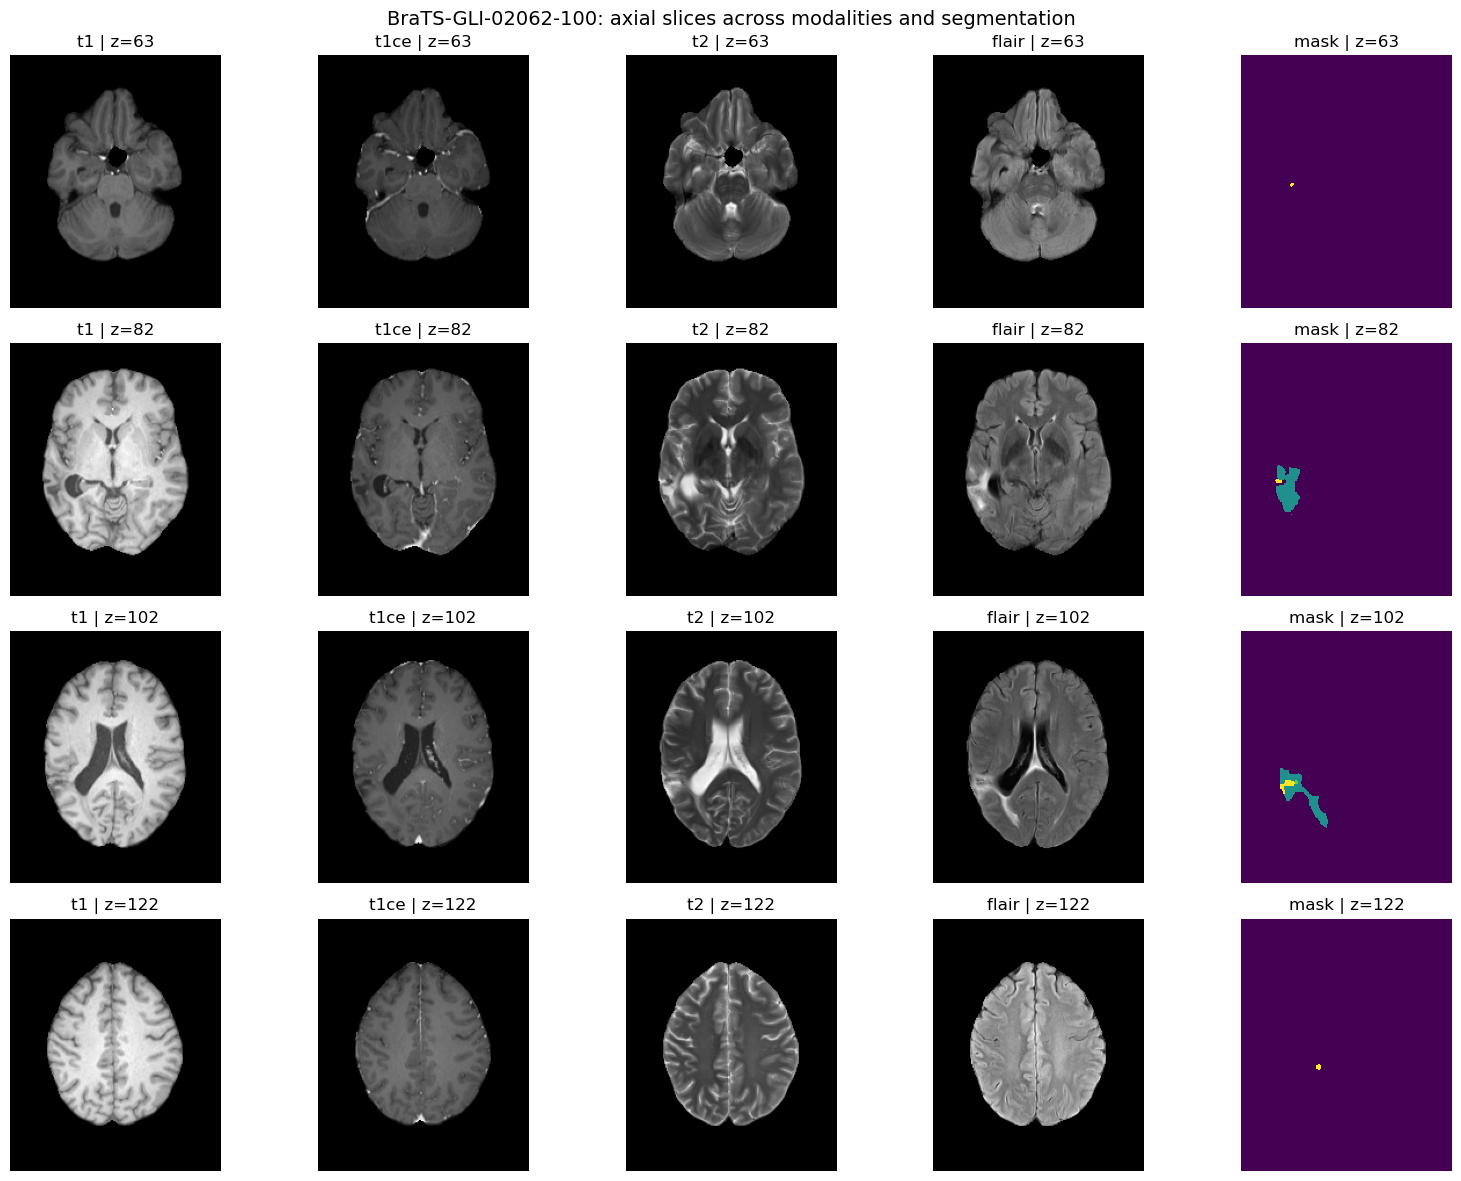

In [9]:
def normalize_slice(slice_2d: np.ndarray) -> np.ndarray:
    slice_2d = slice_2d.astype(np.float32)
    minimum = float(slice_2d.min())
    maximum = float(slice_2d.max())
    return (slice_2d - minimum) / (maximum - minimum + 1e-8)


def choose_axial_slices(label_volume: np.ndarray, count: int = 4) -> list[int]:
    positive_slices = np.where(label_volume.any(axis=(0, 1)))[0]
    if len(positive_slices) >= count:
        return np.linspace(positive_slices[0], positive_slices[-1], num=count, dtype=int).tolist()
    return np.linspace(0, label_volume.shape[2] - 1, num=count, dtype=int).tolist()


def plot_axial_overview(
    modality_volumes: dict[str, np.ndarray],
    mask_volume: np.ndarray,
    case_id: str,
    slice_indices: list[int],
) -> None:
    modality_names = list(modality_volumes)
    figure, axes = plt.subplots(
        nrows=len(slice_indices),
        ncols=len(modality_names) + 1,
        figsize=(3.2 * (len(modality_names) + 1), 3.0 * len(slice_indices)),
    )
    axes = np.atleast_2d(axes)

    for row_index, slice_index in enumerate(slice_indices):
        for col_index, modality_name in enumerate(modality_names):
            image_slice = normalize_slice(modality_volumes[modality_name][:, :, slice_index])
            axes[row_index, col_index].imshow(np.rot90(image_slice), cmap="gray")
            axes[row_index, col_index].set_title(f"{modality_name} | z={slice_index}")
            axes[row_index, col_index].axis("off")

        mask_slice = mask_volume[:, :, slice_index]
        axes[row_index, -1].imshow(np.rot90(mask_slice), cmap="viridis", interpolation="nearest")
        axes[row_index, -1].set_title(f"mask | z={slice_index}")
        axes[row_index, -1].axis("off")

    figure.suptitle(f"{case_id}: axial slices across modalities and segmentation", fontsize=14)
    figure.tight_layout()
    plt.show()


slice_indices = choose_axial_slices(label_array, count=4)
print("Axial slice indices:", slice_indices)

plot_axial_overview(
    modality_volumes=modality_arrays,
    mask_volume=label_array,
    case_id=sample_case["case_id"],
    slice_indices=slice_indices,
)